In [1]:
import os, pathlib
os.chdir("/Users/gregcc/Documents/GitHub/SURP25/Microlensing")
import ML_amber, inspect, sys, importlib

from astropy.io import ascii
import matplotlib.pyplot as plt
import numpy as np
print("Imported ML.py from:", ML_amber.__file__)

Imported ML.py from: /Users/gregcc/Documents/GitHub/SURP25/Microlensing/ML_amber.py


In [2]:
from ML_amber import ThreeLens1S
from ML_amber import TwoLens1S

In [3]:
#parameters from Liebig, et al; (2010)
q2 = 1e-3
q3 = 1e-5
s2 = 1.3
s3 = 1.3003845585056752
psi = 1.393457227228705
q4 = q3 + q2 #for binary system
u0_list =[0.03]


t0 = 0
tE = 20
rho = 1.8e-3
rs = rho

secnum = 45
basenum = 2
num_points = 100

#paper
D_l = 6 #kpc
D_s = 8 #kpc

m1 = 0.3 #Lens Star Mass (Solar Mass)

In [4]:
def Einstein_Radius(M_solar, D_l_kpc, D_s_kpc):
    """
    Computes the Einstein Radius.

    Parameters:
    M_solar : float
        Mass of the lens in Solar masses
    D_l_kpc : float
        Distance to the lens in kpc
    D_s_kpc : float
        Distance to the source in kpc

    Returns:
    R_E : float
        Einstein radius in meters
    theta_E_arcsec : float
        Einstein radius in arcseconds
    theta_E_mas : float
        Einstein radius in milliarcseconds
    """
    # Constants
    c = 3e8            # speed of light in m/s
    G = 6.674e-11      # gravitational constant in N m^2 / kg^2
    M_sun = 1.989e30   # kg
    kpc_to_m = 3.086e19  # meters
    rad_to_arcsec = 206265  # arcsec per radian

    # Convert inputs
    M = M_solar * M_sun
    D_l = D_l_kpc * kpc_to_m
    D_s = D_s_kpc * kpc_to_m
    D_ls = D_s - D_l

    # Einstein radius in meters
    R_E = ((4 * G * M / c**2) * (D_ls * D_l / D_s)) ** 0.5

    # Angular Einstein radius in radians
    theta_E_rad = R_E / D_l

    # Convert to arcsec and mas
    theta_E_arcsec = theta_E_rad * rad_to_arcsec
    theta_E_mas = theta_E_arcsec * 1000

    return R_E, theta_E_arcsec, theta_E_mas

In [5]:
R_E, theta_E_arcsec, theta_E_mas = Einstein_Radius(m1, D_l, D_s)

print(f"Einstein Radius: {R_E:.2e} m")
print(f"Angular Einstein Radius: {theta_E_arcsec:.4f} arcsec")
print(f"Angular Einstein Radius: {theta_E_mas:.2f} mas")

Einstein Radius: 2.86e+11 m
Angular Einstein Radius: 0.0003 arcsec
Angular Einstein Radius: 0.32 mas


In [6]:
#triple system
triple_model = ThreeLens1S(t0, tE, rho, u0_list, q2, q3, s2, s3, 20, psi, rs, secnum, basenum, num_points)

param = [
    np.log(triple_model.s2), np.log(triple_model.q2), triple_model.u0_list[0], triple_model.alpha_deg,
    np.log(triple_model.rho), np.log(triple_model.tE), triple_model.t0,
    np.log(triple_model.s3), np.log(triple_model.q3), triple_model.psi_rad
]
mag, *_ = triple_model.VBM.TripleLightCurve(param, triple_model.highres_t)

triple_model_tau = triple_model.highres_tau
triple_model_mag = mag

In [7]:
#binary system
double_model = TwoLens1S(t0, tE, rho, u0_list, q4, s2, 20, t_lc= triple_model.highres_t )
A_bin = double_model.VBM.BinaryLightCurve([np.log(s2), np.log(q4), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model.highres_t)[0]

binary_model = TwoLens1S(t0, tE, rho, u0_list, q2, s2, 20, t_lc= triple_model.highres_t )
B_bin = binary_model.VBM.BinaryLightCurve([np.log(s2), np.log(q2), u0_list[0], 0,
                                     np.log(rho), np.log(tE), t0], triple_model.highres_t)[0]

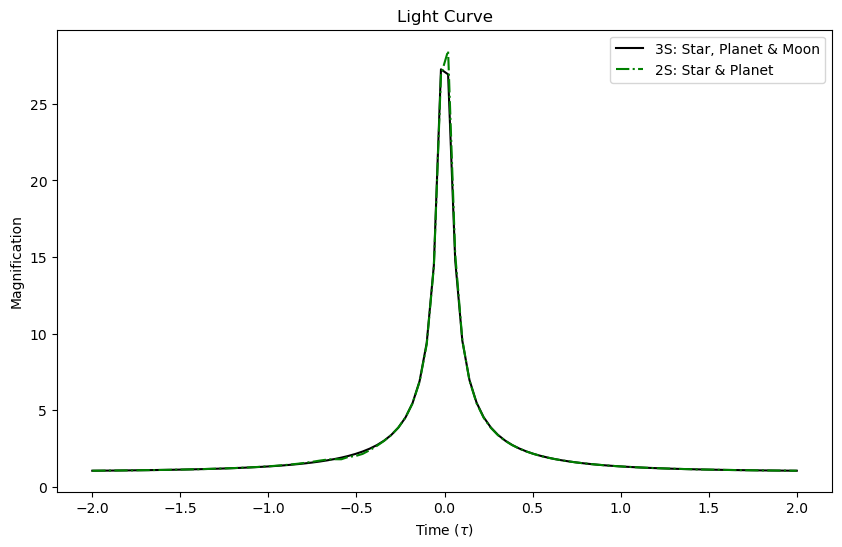

In [8]:
# plot light curve
plt.figure(figsize=(10, 6))
plt.plot(triple_model.highres_tau, triple_model_mag, 'k-', label = "3S: Star, Planet & Moon")
#plt.plot(triple_model_tau, A_bin, '--', label = "2S: Star & (Planet + Moon)", color = 'blue')
plt.plot(triple_model_tau, B_bin, '-.', label = "2S: Star & Planet", color = 'green')

plt.xlabel(r"Time ($\tau$)")
plt.ylabel('Magnification')
plt.title('Light Curve')
#plt.xlim((-0.56, -0.5))
#plt.ylim((0, 11))

plt.legend()

u0=0.03 VB y1[:5]=[1.88964585 1.88022537 1.87080489 1.86138441 1.85196394] y2[:5]=[0.65584951 0.65242073 0.64899196 0.64556319 0.64213441]
u0=0.03 analytic y1[:5]=[1.88964585 1.88022537 1.87080489 1.86138441 1.85196394] y2[:5]=[0.65584951 0.65242073 0.64899196 0.64556319 0.64213441]


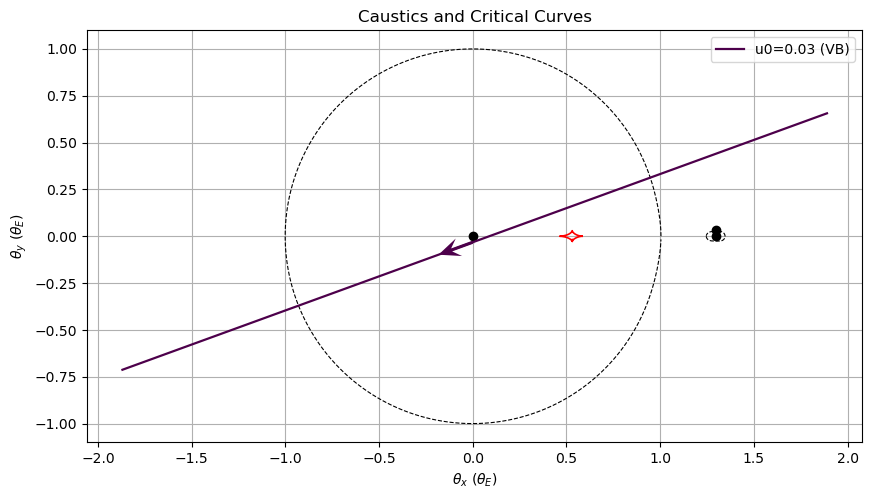

In [9]:
triple_model.plot_caustics_and_critical(show = False)
ax = plt.gca()
#ax.set_xlim(0.450, 0.60)
#ax.set_ylim(-0.05, 0.035)

ax.set_xlabel(r"$\theta_x$ ($\theta_E$)")
ax.set_ylabel(r"$\theta_y$ ($\theta_E$)")
ax.set_title("Caustics and Critical Curves")

plt.show()

In [10]:
#Setting Up Centroids
two_system    = double_model.systems[0]
binary_system = binary_model.systems[0]
three_system  = triple_model.systems[0]

# 2L1S 
delta_x_two = two_system['cent_x_lc'] - two_system['y1s_lc']
delta_y_two = two_system['cent_y_lc'] - two_system['y2s_lc']

delta_x_two_B = binary_system['cent_x_lc'] - binary_system['y1s_lc']
delta_y_two_B = binary_system['cent_y_lc'] - binary_system['y2s_lc']

# 3L1S 
delta_x_three = three_system['cent_x'] - three_system['y1s']
delta_y_three = three_system['cent_y'] - three_system['y2s']

delta_x_three = delta_x_three
delta_y_three = -delta_y_three

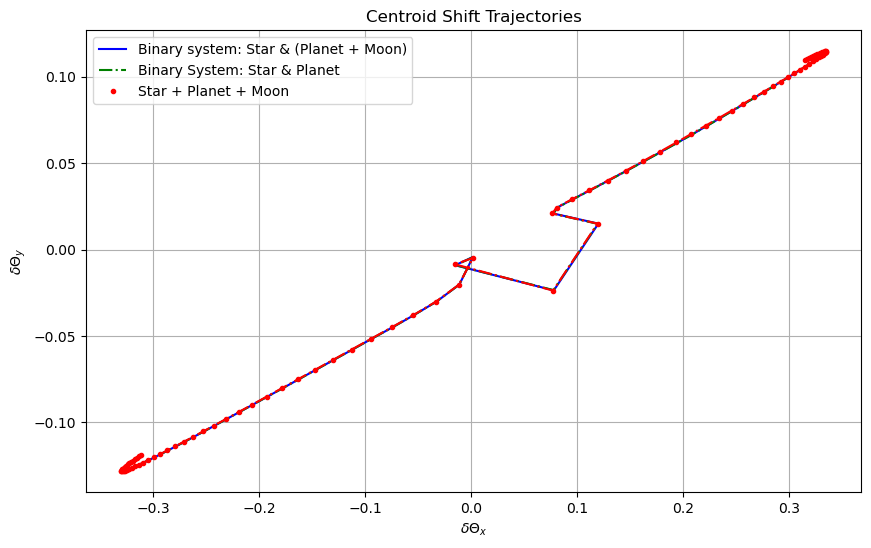

In [11]:
#centroid
plt.figure(figsize=(10, 6))
plt.plot(delta_x_two, delta_y_two, 'b-', label='Binary system: Star & (Planet + Moon)')
plt.plot(delta_x_two_B, delta_y_two_B, 'g-.', label='Binary System: Star & Planet')
plt.plot(delta_x_three, delta_y_three, 'r.', label='Star + Planet + Moon')
plt.plot(delta_x_three, delta_y_three, 'r-.')


plt.xlabel(r"$\delta \Theta_x$")
plt.ylabel(r"$\delta \Theta_y$")
plt.title("Centroid Shift Trajectories")
plt.grid(True)

plt.legend()

plt.show()

In [12]:
delta_triple = (delta_x_three**2 + delta_y_three**2)**0.5
delta_double_A = (delta_x_two**2 + delta_y_two**2)**0.5
delta_double_B = (delta_x_two_B**2 + delta_y_two_B**2)**0.5

delta_triple = delta_triple[::-1]


In [13]:
#setting up residual plots
res_triple = delta_double_B - delta_triple
res_double = delta_double_B - delta_double_A

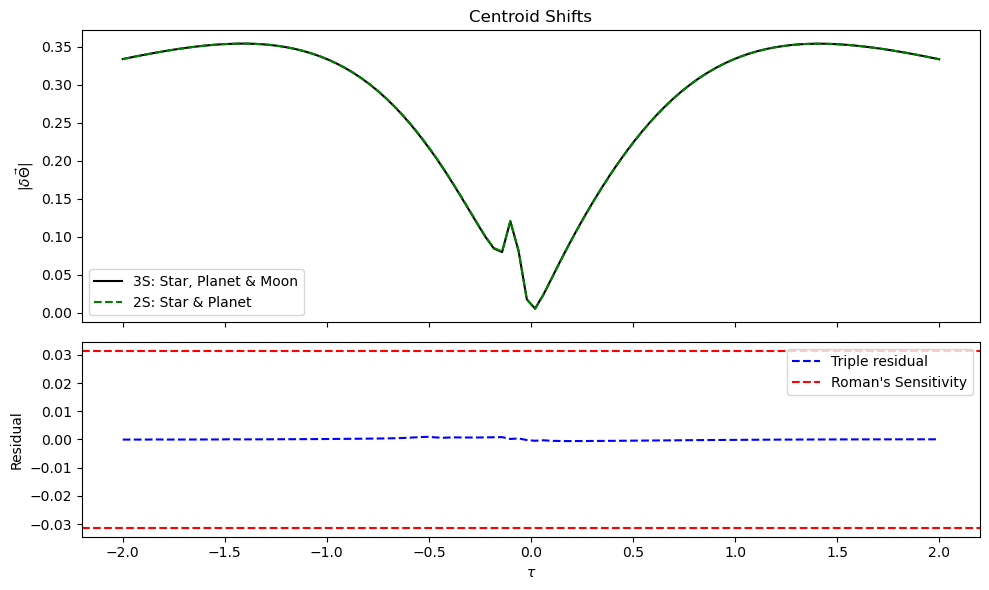

In [14]:
# Roman sensitivity in θE units
thetaE_mas = theta_E_mas
roman_sensitivity = 0.01 / thetaE_mas   # 10 µas = 0.01 mas

fig, axes = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True,
    gridspec_kw={'height_ratios': [3, 2]}  # top 3x taller than bottom
)

# --- Top panel: centroid shifts ---
#axes[0].plot(triple_model_tau, delta_double_A, 'b--', label="2S: Star & (Planet + Moon)")
axes[0].plot(triple_model_tau, delta_triple, 'k-', label="3S: Star, Planet & Moon")
axes[0].plot(triple_model_tau, delta_double_B,'g--', label="2S: Star & Planet")
axes[0].set_ylabel(r"$|\delta \vec{\Theta}|$")
axes[0].set_title("Centroid Shifts")
axes[0].legend()

# --- Bottom panel: residuals ---
axes[1].plot(triple_model_tau, res_triple, 'b--', label="Triple residual")
#axes[1].plot(triple_model_tau, res_double, 'b--', label="Double residual")
axes[1].axhline(roman_sensitivity, color="red", linestyle="--", label="Roman's Sensitivity")
axes[1].axhline(-roman_sensitivity, color="red", linestyle="--")
axes[1].set_xlabel(r"$\tau$")
axes[1].set_ylabel("Residual")
#axes[1].set_title("Residuals")
axes[1].legend()

plt.tight_layout()
plt.show()

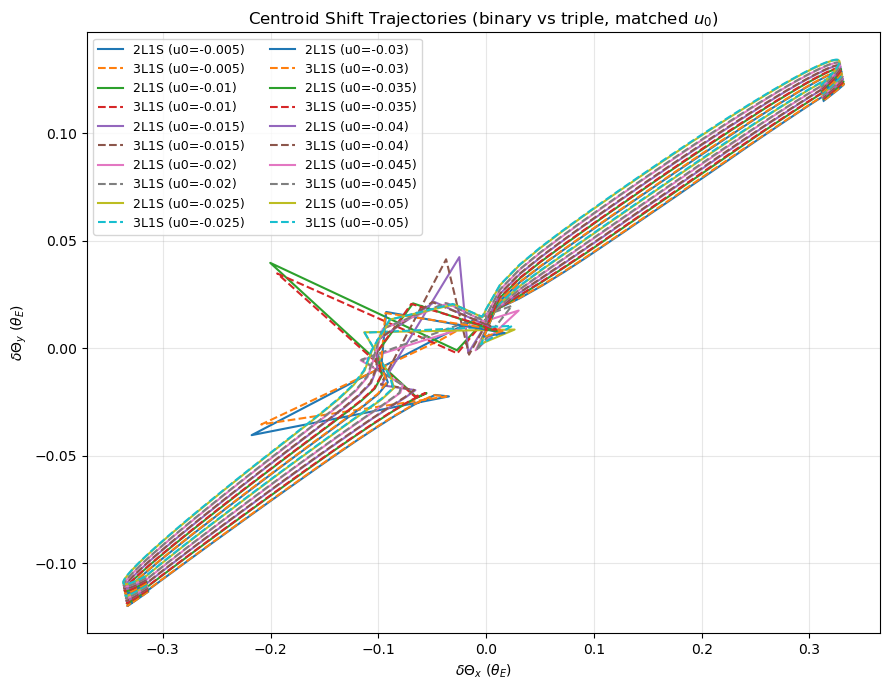

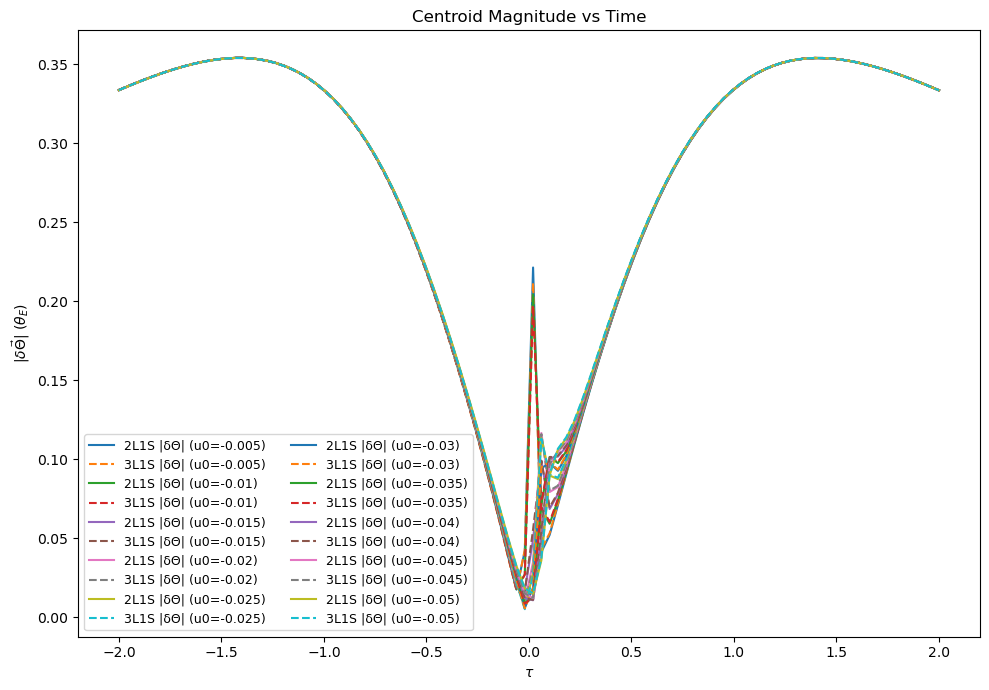

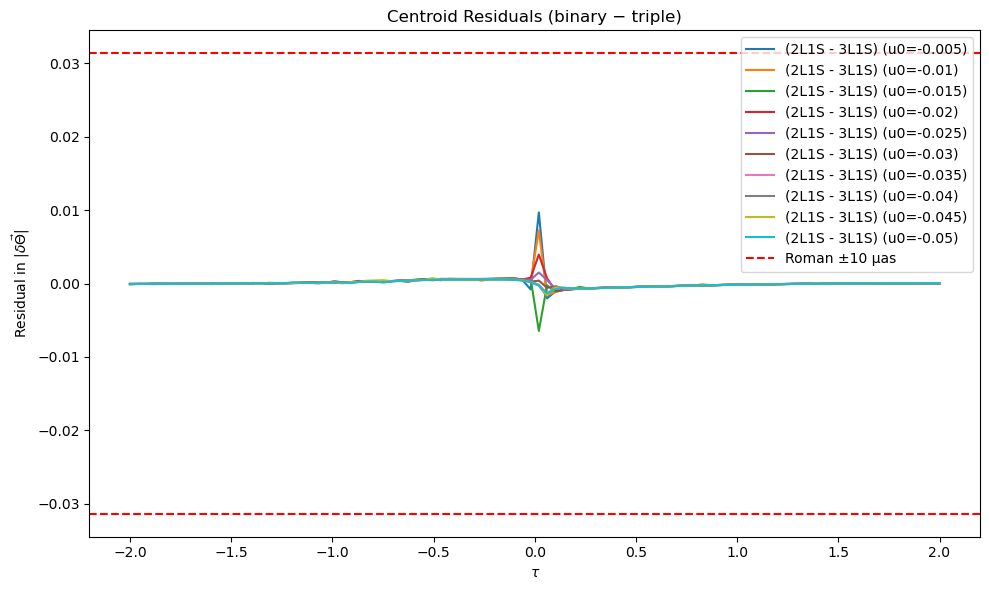

In [ ]:
# --- choose the u0 values you want to compare ---
u0_values = [-0.005, -0.010, -0.015, -0.020, -0.025, 
             -0.030, -0.035, -0.040, -0.045, -0.050]   # edit as you like

# --- constants & shared params (from your snippet) ---
q2 = 1e-3
q3 = 1e-5
s2 = 1.3
s3 = 1.3003845585056752
psi = 1.393457227228705
q4 = q2 + q3
t0 = 0
tE = 20
rho = 1.8e-3
rs  = rho
secnum   = 45
basenum  = 2
num_points = 10000
alpha_deg = 20

# --- set your θ_E (mas) if not already defined elsewhere ---
# theta_E_mas = <your value here>
roman_sensitivity = 0.01 / theta_E_mas   # 10 µas = 0.01 mas

# --- storage for results ---
results = {}

for u0 in u0_values:
    # models on the SAME time grid
    u0_list = [u0]

    triple_model = ThreeLens1S(
        t0, tE, rho, u0_list, q2, q3, s2, s3, alpha_deg, psi, rs,
        secnum, basenum, num_points
    )

    # Force the binary to compute on the triple's high-res time grid for 1:1 alignment
    binary_model = TwoLens1S(
        t0, tE, rho, u0_list, q2, s2, alpha_deg, t_lc=triple_model.highres_t
    )

    # pull time & tau once
    t_hr   = triple_model.highres_t
    tau_hr = triple_model.highres_tau

    # --- systems ---
    bin_sys = binary_model.systems[0]
    tri_sys = triple_model.systems[0]

    # Prefer the *same* resolution suffix for both. We'll try *_lc* first since we passed t_lc.
    def get_xy(sys, prefer='lc'):
        # returns (cent_x, cent_y, y1s, y2s)
        if prefer == 'lc' and all(k in sys for k in ('cent_x_lc','cent_y_lc','y1s_lc','y2s_lc')):
            return sys['cent_x_lc'], sys['cent_y_lc'], sys['y1s_lc'], sys['y2s_lc']
        # fallbacks (hr or base keys) in case naming differs in your class
        elif all(k in sys for k in ('cent_x_hr','cent_y_hr','y1s_hr','y2s_hr')):
            return sys['cent_x_hr'], sys['cent_y_hr'], sys['y1s_hr'], sys['y2s_hr']
        else:
            return sys['cent_x'], sys['cent_y'], sys['y1s'], sys['y2s']

    b_cx, b_cy, b_y1, b_y2 = get_xy(bin_sys, prefer='lc')
    t_cx, t_cy, t_y1, t_y2 = get_xy(tri_sys, prefer='lc')  # use same preference for alignment

    # --- centroid components (shift relative to source position) ---
    dx_bin = b_cx - b_y1
    dy_bin = b_cy - b_y2

    dx_tri = t_cx - t_y1
    dy_tri = t_cy - t_y2

    # match your plotting convention (flip y if you prefer that view)
    dy_tri = -dy_tri
    

    # magnitudes
    delta_bin = np.sqrt(dx_bin**2 + dy_bin**2)
    delta_tri = np.sqrt(dx_tri**2 + dy_tri**2)
    delta_tri = delta_tri[::-1]

    # residuals: (binary - triple)
    res = (delta_bin - delta_tri)

    # store
    results[u0] = dict(
        tau=tau_hr,
        dx_tri=dx_tri, dy_tri=dy_tri, delta_tri=delta_tri,
        dx_bin=dx_bin, dy_bin=dy_bin, delta_bin=delta_bin,
        res=res
    )

# ------------------------- PLOTS -------------------------
import matplotlib.pyplot as plt

# 1) 2-D centroid trajectories per u0
plt.figure(figsize=(9,7))
for u0, R in results.items():
    plt.plot(R['dx_bin'], R['dy_bin'],  '-',  label=fr'2L1S (u0={u0:g})')
    plt.plot(R['dx_tri'], R['dy_tri'], '--',  label=fr'3L1S (u0={u0:g})')
plt.xlabel(r'$\delta \Theta_x\ (\theta_E)$')
plt.ylabel(r'$\delta \Theta_y\ (\theta_E)$')
plt.title('Centroid Shift Trajectories (binary vs triple, matched $u_0$)')
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# 2) |δΘ| vs τ (overlay each u0 as a pair: binary solid, triple dashed)
plt.figure(figsize=(10,7))
for u0, R in results.items():
    plt.plot(R['tau'], R['delta_bin'],  '-',  label=fr'2L1S |δΘ| (u0={u0:g})')
    plt.plot(R['tau'], R['delta_tri'], '--',  label=fr'3L1S |δΘ| (u0={u0:g})')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$|\delta \vec{\Theta}| \ (\theta_E)$')
plt.title('Centroid Magnitude vs Time')
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# 3) Residuals vs τ with Roman sensitivity bands
plt.figure(figsize=(10,6))
for u0, R in results.items():
    plt.plot(R['tau'], R['res'], label=fr'(2L1S - 3L1S) (u0={u0:g})')
plt.axhline( roman_sensitivity, linestyle='--', label="Roman ±10 µas", color='red')
plt.axhline(-roman_sensitivity, linestyle='--', color='red')
plt.xlabel(r'$\tau$')
plt.ylabel(r"Residual in $|\delta \vec{\Theta}|$")
plt.title('Centroid Residuals (binary − triple)')
plt.legend()
plt.tight_layout()
plt.show()


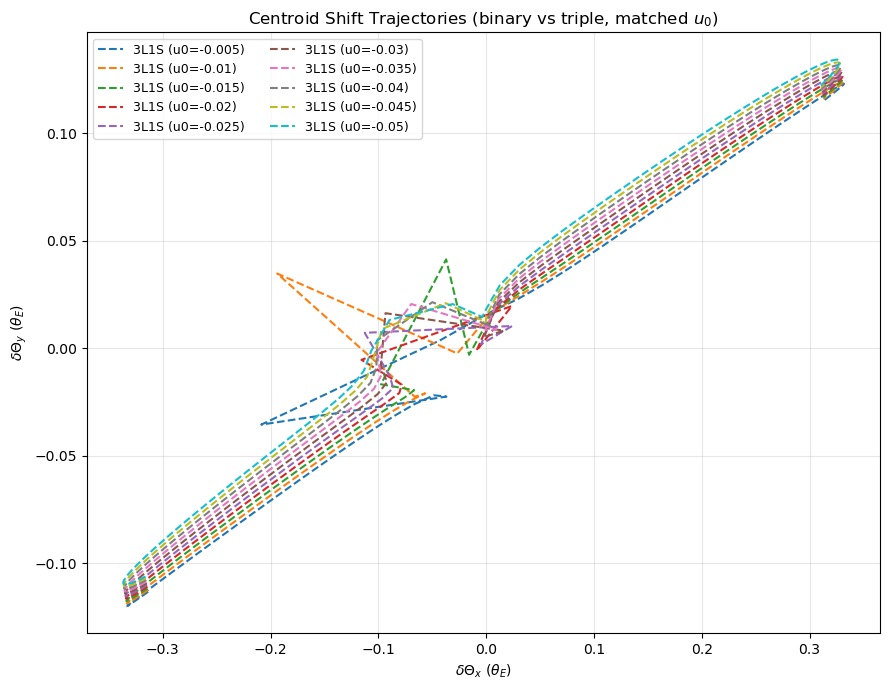

In [17]:
# 1) 2-D centroid trajectories per u0
plt.figure(figsize=(9,7))
for u0, R in results.items():
    #plt.plot(R['dx_bin'], R['dy_bin'],  '-',  label=fr'2L1S (u0={u0:g})')
    plt.plot(R['dx_tri'], R['dy_tri'], '--',  label=fr'3L1S (u0={u0:g})')
plt.xlabel(r'$\delta \Theta_x\ (\theta_E)$')
plt.ylabel(r'$\delta \Theta_y\ (\theta_E)$')
plt.title('Centroid Shift Trajectories (binary vs triple, matched $u_0$)')
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

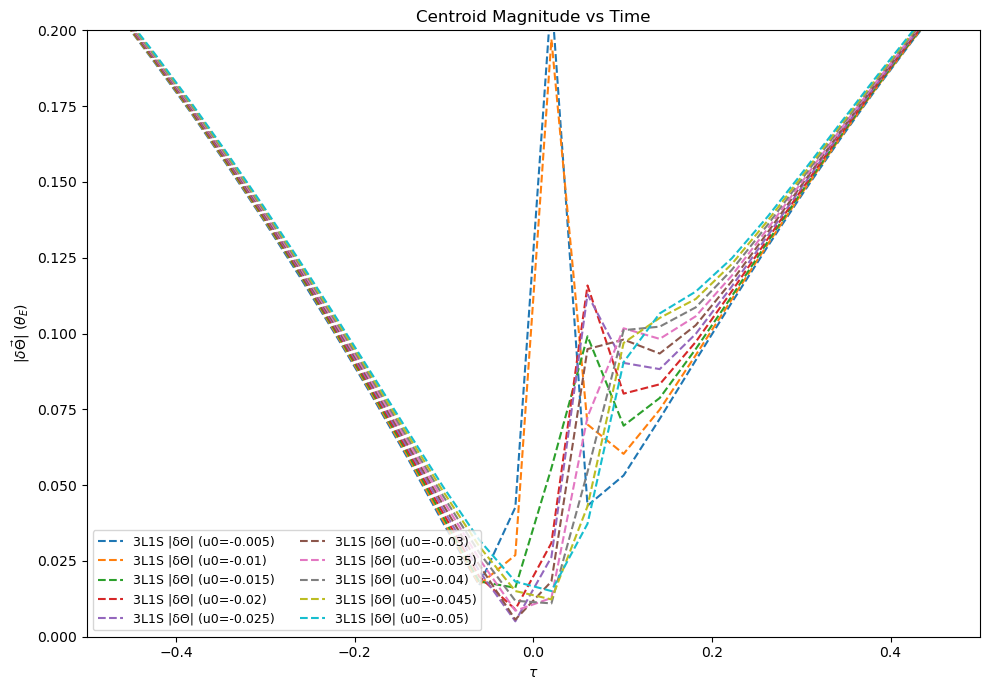

In [18]:
# 2) |δΘ| vs τ (overlay each u0 as a pair: binary solid, triple dashed)
plt.figure(figsize=(10,7))
for u0, R in results.items():
    #plt.plot(R['tau'], R['delta_bin'],  '-',  label=fr'2L1S |δΘ| (u0={u0:g})')
    plt.plot(R['tau'], R['delta_tri'], '--',  label=fr'3L1S |δΘ| (u0={u0:g})')

plt.xlabel(r'$\tau$')
plt.ylabel(r'$|\delta \vec{\Theta}| \ (\theta_E)$')

plt.xlim(-0.5, 0.5)
plt.ylim(0, 0.2)
plt.title('Centroid Magnitude vs Time')
plt.legend(loc = 'lower left', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()